# Home Assignment — Module 2: IPO Buy-and-Hold Strategy

**السؤال:** بعد الاكتتاب العام (IPO) بيحصل "bump" في السعر، وبعدين السعر بيهبط.
المطلوب: تصميم استراتيجية **buy & hold لمدة X يوم تداول** (بسعر `Adj Close`، من غير عمولات)، وإيجاد أفضل X بين 1 و 30 يعطي أعلى **mean return** على اكتتابات 2023، ثم اختبار نفس X على بيانات 2024 (Out-of-Sample).

هذا الـ notebook يحل الواجب كامل خطوة بخطوة، مبني على `stacked_ipos_df` و `yfinance` بالظبط زي ما اتعمل فوق في الدرس.

## 0) Imports

In [1]:
import numpy as np
import pandas as pd
import requests
import time

import yfinance as yf

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

pd.options.mode.chained_assignment = None  # default='warn'


## 1) تحميل وتنظيف بيانات الاكتتابات (IPOs) لسنتي 2023 و 2024

بنجيب الجدول من `stockanalysis.com` لكل سنة على حدة، ثم نعمل `pd.concat` (stacking) في `stacked_ipos_df`،
وبعدين ننضّف الأعمدة الرقمية (`IPO Price`, `Current`, `Return`) باستخدام `pd.to_numeric(errors='coerce')`
عشان أي قيمة ناقصة زي `'-'` تتحول لـ `NaN` بدل ما تكسر الكود.

In [2]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                  '(KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3',
}

def fetch_ipo_year(year: int) -> pd.DataFrame:
    """يجيب جدول اكتتابات سنة معينة من stockanalysis.com"""
    url = f"https://stockanalysis.com/ipos/{year}/"
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()
    dfs = pd.read_html(response.text)
    df = dfs[0].copy()
    df['IPO_Year'] = year   # نضيف عمود يوضح السنة عشان نقدر نفصل بعدين
    return df

ipos_2023 = fetch_ipo_year(2023)
ipos_2024 = fetch_ipo_year(2024)

print("2023 shape:", ipos_2023.shape)
print("2024 shape:", ipos_2024.shape)
ipos_2023.head(3)


/tmp/ipykernel_1852/2158664939.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(response.text)


2023 shape: (154, 7)
2024 shape: (226, 7)


/tmp/ipykernel_1852/2158664939.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(response.text)


,IPO Date,Symbol,Company Name,IPO Price,Current,Return,IPO_Year
0,"Dec 27, 2023",IROH,Iron Horse Acquisitions Corp.,$10.00,$4.09,-25.00%,2023
1,"Dec 19, 2023",UZX,Linkage Global Inc,-,$0.081,-,2023
2,"Dec 15, 2023",BAYA,Bayview Acquisition Corp,$10.00,$12.14,21.40%,2023


In [3]:
# "stacking" الجدولين فوق بعض (UNION ALL) في DataFrame واحد
stacked_ipos_df = pd.concat([ipos_2023, ipos_2024], ignore_index=True)
print(stacked_ipos_df.shape)
stacked_ipos_df.head(3)


(380, 7)


,IPO Date,Symbol,Company Name,IPO Price,Current,Return,IPO_Year
0,"Dec 27, 2023",IROH,Iron Horse Acquisitions Corp.,$10.00,$4.09,-25.00%,2023
1,"Dec 19, 2023",UZX,Linkage Global Inc,-,$0.081,-,2023
2,"Dec 15, 2023",BAYA,Bayview Acquisition Corp,$10.00,$12.14,21.40%,2023


In [4]:
# تحويل تاريخ الاكتتاب لـ datetime
stacked_ipos_df['IPO Date'] = pd.to_datetime(stacked_ipos_df['IPO Date'])

# تنظيف الأعمدة الرقمية: شيل $ و % واستخدم errors='coerce' عشان القيم الناقصة زي '-' تتحول NaN
stacked_ipos_df['IPO Price'] = pd.to_numeric(
    stacked_ipos_df['IPO Price'].astype(str).str.replace('$', '', regex=False),
    errors='coerce'
)
stacked_ipos_df['Current'] = pd.to_numeric(
    stacked_ipos_df['Current'].astype(str).str.replace('$', '', regex=False),
    errors='coerce'
)
stacked_ipos_df['Return'] = pd.to_numeric(
    stacked_ipos_df['Return'].astype(str).str.replace('%', '', regex=False),
    errors='coerce'
) / 100

print(stacked_ipos_df.info())
print()
print("NULLs per column:")
print(stacked_ipos_df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   IPO Date      380 non-null    datetime64[ns]
 1   Symbol        380 non-null    object        
 2   Company Name  380 non-null    object        
 3   IPO Price     362 non-null    float64       
 4   Current       378 non-null    float64       
 5   Return        359 non-null    float64       
 6   IPO_Year      380 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 20.9+ KB
None

NULLs per column:
IPO Date         0
Symbol           0
Company Name     0
IPO Price       18
Current          2
Return          21
IPO_Year         0
dtype: int64


In [5]:
# شيل أي صفوف الـ Symbol فيها فاضي (مينفعش نجيب بيانات سهم من غير رمز)
stacked_ipos_df = stacked_ipos_df.dropna(subset=['Symbol']).reset_index(drop=True)
stacked_ipos_df['Symbol'] = stacked_ipos_df['Symbol'].astype(str).str.strip()

print("Final stacked_ipos_df shape:", stacked_ipos_df.shape)
stacked_ipos_df[['IPO Date', 'Symbol', 'Company Name', 'IPO Price', 'Current', 'Return', 'IPO_Year']].head()


Final stacked_ipos_df shape: (380, 7)


,IPO Date,Symbol,Company Name,IPO Price,Current,Return,IPO_Year
0,2023-12-27,IROH,Iron Horse Acquisitions Corp.,10.0,4.090,-0.2500,2023
1,2023-12-19,UZX,Linkage Global Inc,NaN,0.081,NaN,2023
2,2023-12-15,BAYA,Bayview Acquisition Corp,10.0,12.140,0.2140,2023
3,2023-12-15,ZKH,ZKH Group Limited,15.5,2.940,-0.8103,2023
4,2023-12-14,INHD,Inno Holdings Inc.,4.0,3.050,-0.2375,2023


## 2) تحميل بيانات الأسهم التاريخية لكل IPO (yfinance)

بنجيب `Symbols` الفريدة، وبعدين نحمّل بيانات كل سهم بـ `yf.download(period="max", interval="1d")`
مع `try/except` عشان أي سهم يفشل (اتشطب من البورصة، أو الرمز اتغيّر) ما يوقفش باقي الكود.

In [6]:
all_symbols = sorted(stacked_ipos_df['Symbol'].unique().tolist())
print(f"Number of unique IPO symbols: {len(all_symbols)}")

stock_data = {}
failed_symbols = []

BATCH_SIZE = 20  # نزل البيانات على دفعات عشان نقلل عدد الـ requests ونسرّع التحميل

for i in range(0, len(all_symbols), BATCH_SIZE):
    batch = all_symbols[i:i + BATCH_SIZE]
    try:
        # batch download: بيرجع MultiIndex columns لو أكتر من ticker
        batch_data = yf.download(
            tickers=batch,
            period="max",
            interval="1d",
            group_by='ticker',
            threads=True,
            progress=False,
        )
    except Exception as e:
        print(f"[WARN] Batch download failed for {batch}: {e}")
        batch_data = None

    for symbol in batch:
        try:
            if batch_data is not None and isinstance(batch_data.columns, pd.MultiIndex) and symbol in batch_data.columns.get_level_values(0):
                df = batch_data[symbol].dropna(how='all')
            else:
                # fallback: تحميل فردي لو الـ batch مكانش فيه السهم ده
                df = yf.download(tickers=symbol, period="max", interval="1d", progress=False)

            if df is None or df.empty:
                raise ValueError("Empty dataframe returned")

            df = df.sort_index()
            stock_data[symbol] = df
        except Exception as e:
            print(f"[WARN] Could not download data for {symbol}: {e}")
            failed_symbols.append(symbol)

    time.sleep(0.5)  # احترام لسيرفر Yahoo، تجنّب الـ rate limiting

print(f"\nSuccessfully downloaded: {len(stock_data)} symbols")
print(f"Failed: {len(failed_symbols)} symbols -> {failed_symbols[:20]}{'...' if len(failed_symbols) > 20 else ''}")


Number of unique IPO symbols: 380


/tmp/ipykernel_1852/3545237506.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  batch_data = yf.download(
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AAM"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AITR"}}}
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['AAM', 'AITR', 'AACT', 'ALCY']: YFTzMissingError('possibly delisted; no timezone found')


[WARN] Could not download data for AACT: Empty dataframe returned
[WARN] Could not download data for AAM: Empty dataframe returned
[WARN] Could not download data for AITR: Empty dataframe returned
[WARN] Could not download data for ALCY: Empty dataframe returned


/tmp/ipykernel_1852/3545237506.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  batch_data = yf.download(
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['BAYA', 'BACQ']: YFTzMissingError('possibly delisted; no timezone found')


[WARN] Could not download data for BACQ: Empty dataframe returned
[WARN] Could not download data for BAYA: Empty dataframe returned


...

[WARN] Could not download data for TBMC: Empty dataframe returned
[WARN] Could not download data for TMTC: Empty dataframe returned
[WARN] Could not download data for TSBX: Empty dataframe returned


/tmp/ipykernel_1852/3545237506.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  batch_data = yf.download(
ERROR:yfinance:
5 Failed downloads:
ERROR:yfinance:['WAI', 'WLGS', 'VCIC', 'WLAC', 'VACH']: YFTzMissingError('possibly delisted; no timezone found')


[WARN] Could not download data for VACH: Empty dataframe returned
[WARN] Could not download data for VCIC: Empty dataframe returned
[WARN] Could not download data for WAI: Empty dataframe returned
[WARN] Could not download data for WLAC: Empty dataframe returned
[WARN] Could not download data for WLGS: Empty dataframe returned


/tmp/ipykernel_1852/3545237506.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  batch_data = yf.download(
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['WRNT', 'ZK']: YFTzMissingError('possibly delisted; no timezone found')


[WARN] Could not download data for WRNT: Empty dataframe returned
[WARN] Could not download data for ZK: Empty dataframe returned

Successfully downloaded: 307 symbols
Failed: 73 symbols -> ['AACT', 'AAM', 'AITR', 'ALCY', 'BACQ', 'BAYA', 'BLAC', 'BLMZ', 'BOWN', 'BREA', 'BSII', 'BUJA', 'CCIR', 'CEP', 'CETU', 'CHEB', 'CHRO', 'CRGX', 'DIST', 'DTCK']...


## 3) حساب عائد استراتيجية Buy-and-Hold لكل X من 1 إلى 30 يوم تداول

**الطريقة:**
1. لكل سهم، نرتّب بياناته حسب التاريخ تصاعديًا.
2. سعر الشراء = `Adj Close` في **أول يوم تداول عند أو بعد تاريخ الـ IPO** (مش بالضرورة نفس اليوم، لأن IPO ممكن يقع في عطلة).
3. سعر البيع بعد X يوم تداول = بنستخدم **positional indexing (`.iloc`)** — يعني نتحرك X خانة للأمام في السلسلة المرتّبة، مش نضيف X يوم على التاريخ (لأن ده هيقع أحيانًا في عطلة/ويكند).
4. العائد = `(sell_price - buy_price) / buy_price`.
5. لو مفيش بيانات كافية بعد الشراء بـ X يوم، أو الـ Adj Close فاضي، بنحط `NaN` بدل ما نكسر الحساب.

In [8]:
if stock_data:
    sample = next(iter(stock_data))
    print("Sample columns:", stock_data[sample].columns.tolist())
    print(stock_data[sample].tail(2))

Sample columns: ['Open', 'High', 'Low', 'Close', 'Volume']
Price       Open  High    Low  Close    Volume
Date                                          
2026-09-17  1.04  1.05  0.963  0.995  174500.0
2026-09-18  1.00  1.03  0.960  0.981  113100.0


In [7]:
MAX_X = 30

def compute_buy_hold_returns(symbol: str, ipo_date: pd.Timestamp, df: pd.DataFrame, max_x: int = MAX_X):
    """
    يحسب عائد buy & hold لمدة X يوم تداول (X من 1 لـ max_x) لسهم واحد.
    بيرجع dict {'return_1d': ..., ..., 'return_30d': ...} أو None لو مفيش بيانات كافية.
    """
    if df is None or df.empty or 'Adj Close' not in df.columns:
        return None

    df_sorted = df.sort_index()
    adj_close = df_sorted['Adj Close']

    # أقرب يوم تداول عند أو بعد تاريخ الـ IPO
    valid_dates = df_sorted.index[df_sorted.index >= ipo_date]
    if len(valid_dates) == 0:
        return None

    buy_date = valid_dates[0]
    buy_pos = df_sorted.index.get_loc(buy_date)
    buy_price = adj_close.iloc[buy_pos]

    if pd.isna(buy_price) or buy_price == 0:
        return None

    result = {}
    for x in range(1, max_x + 1):
        sell_pos = buy_pos + x   # positional indexing -- X خانة تداول للأمام
        if sell_pos >= len(df_sorted):
            result[f'return_{x}d'] = np.nan
            continue
        sell_price = adj_close.iloc[sell_pos]
        if pd.isna(sell_price):
            result[f'return_{x}d'] = np.nan
        else:
            result[f'return_{x}d'] = (sell_price - buy_price) / buy_price

    return result


def build_returns_matrix(ipos_subset: pd.DataFrame, stock_data: dict, max_x: int = MAX_X) -> pd.DataFrame:
    """يبني DataFrame: index = Symbol, columns = return_1d..return_Xd لمجموعة اكتتابات معيّنة"""
    rows = {}
    for _, row in ipos_subset.iterrows():
        symbol = row['Symbol']
        ipo_date = row['IPO Date']

        if pd.isna(ipo_date) or symbol not in stock_data:
            continue

        res = compute_buy_hold_returns(symbol, ipo_date, stock_data[symbol], max_x=max_x)
        if res is not None:
            rows[symbol] = res

    returns_df = pd.DataFrame(rows).T
    returns_df = returns_df[[f'return_{x}d' for x in range(1, max_x + 1)]]
    return returns_df


ipos_2023_clean = stacked_ipos_df[stacked_ipos_df['IPO_Year'] == 2023].copy()
ipos_2024_clean = stacked_ipos_df[stacked_ipos_df['IPO_Year'] == 2024].copy()

returns_2023_df = build_returns_matrix(ipos_2023_clean, stock_data, max_x=MAX_X)
returns_2024_df = build_returns_matrix(ipos_2024_clean, stock_data, max_x=MAX_X)

print("returns_2023_df shape:", returns_2023_df.shape)
print("returns_2024_df shape:", returns_2024_df.shape)
returns_2023_df.head()


KeyError: "None of [Index(['return_1d', 'return_2d', 'return_3d', 'return_4d', 'return_5d',\n       'return_6d', 'return_7d', 'return_8d', 'return_9d', 'return_10d',\n       'return_11d', 'return_12d', 'return_13d', 'return_14d', 'return_15d',\n       'return_16d', 'return_17d', 'return_18d', 'return_19d', 'return_20d',\n       'return_21d', 'return_22d', 'return_23d', 'return_24d', 'return_25d',\n       'return_26d', 'return_27d', 'return_28d', 'return_29d', 'return_30d'],\n      dtype='object')] are in the [columns]"

In [9]:
MAX_X = 30

def compute_buy_hold_returns(symbol: str, ipo_date: pd.Timestamp, df: pd.DataFrame, max_x: int = MAX_X):
    """
    يحسب عائد buy & hold لمدة X يوم تداول (X من 1 لـ max_x) لسهم واحد.
    بيرجع dict {'return_1d': ..., ..., 'return_30d': ...} أو None لو مفيش بيانات كافية.
    """
    if df is None or df.empty:
        return None

    # ✅ yfinance الجديد بيرجّع 'Close' بس (مفيش 'Adj Close')
    if 'Adj Close' in df.columns:
        price_col = 'Adj Close'
    elif 'Close' in df.columns:
        price_col = 'Close'
    else:
        return None

    df_sorted = df.sort_index()
    price_series = df_sorted[price_col].dropna()

    if price_series.empty:
        return None

    # أقرب يوم تداول عند أو بعد تاريخ الـ IPO
    valid_dates = price_series.index[price_series.index >= ipo_date]
    if len(valid_dates) == 0:
        return None

    buy_date = valid_dates[0]
    buy_pos = price_series.index.get_loc(buy_date)
    buy_price = price_series.iloc[buy_pos]

    if pd.isna(buy_price) or buy_price == 0:
        return None

    result = {}
    for x in range(1, max_x + 1):
        sell_pos = buy_pos + x   # positional indexing -- X خانة تداول للأمام
        if sell_pos >= len(price_series):
            result[f'return_{x}d'] = np.nan
            continue
        sell_price = price_series.iloc[sell_pos]
        result[f'return_{x}d'] = (
            (sell_price - buy_price) / buy_price if pd.notna(sell_price) else np.nan
        )

    return result


def build_returns_matrix(ipos_subset: pd.DataFrame, stock_data: dict, max_x: int = MAX_X) -> pd.DataFrame:
    """يبني DataFrame: index = Symbol, columns = return_1d..return_Xd لمجموعة اكتتابات معيّنة"""
    rows = {}
    for _, row in ipos_subset.iterrows():
        symbol = row['Symbol']
        ipo_date = row['IPO Date']

        if pd.isna(ipo_date) or symbol not in stock_data:
            continue

        res = compute_buy_hold_returns(symbol, ipo_date, stock_data[symbol], max_x=max_x)
        if res is not None:
            rows[symbol] = res

    expected_cols = [f'return_{x}d' for x in range(1, max_x + 1)]

    # ✅ حماية من الحالة الفاضية
    if not rows:
        print("[WARN] build_returns_matrix: no valid rows. "
              "Check stock_data / price column / IPO dates.")
        return pd.DataFrame(columns=expected_cols)

    returns_df = pd.DataFrame(rows).T
    # ✅ reindex بدل fancy indexing — آمن لو أي عمود ناقص
    returns_df = returns_df.reindex(columns=expected_cols)
    return returns_df


ipos_2023_clean = stacked_ipos_df[stacked_ipos_df['IPO_Year'] == 2023].copy()
ipos_2024_clean = stacked_ipos_df[stacked_ipos_df['IPO_Year'] == 2024].copy()

returns_2023_df = build_returns_matrix(ipos_2023_clean, stock_data, max_x=MAX_X)
returns_2024_df = build_returns_matrix(ipos_2024_clean, stock_data, max_x=MAX_X)

print("returns_2023_df shape:", returns_2023_df.shape)
print("returns_2024_df shape:", returns_2024_df.shape)
returns_2023_df.head()

returns_2023_df shape: (108, 30)
returns_2024_df shape: (199, 30)


,return_1d,return_2d,return_3d,return_4d,return_5d,return_6d,return_7d,return_8d,return_9d,return_10d,...,return_21d,return_22d,return_23d,return_24d,return_25d,return_26d,return_27d,return_28d,return_29d,return_30d
UZX,0.000000,-0.034483,0.282183,0.176436,0.205517,0.275574,0.066724,0.123563,0.057471,0.048218,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZKH,0.000000,0.000000,0.011613,0.008387,0.003871,0.029032,0.025806,0.040000,0.052258,0.019355,...,0.079355,0.038710,0.045161,0.084516,0.194839,0.228387,0.106452,0.145161,0.169032,0.100645
INHD,-0.846431,-0.866619,-0.877794,-0.886806,-0.891853,-0.892574,-0.900505,-0.909877,-0.891492,-0.896179,...,-0.922134,-0.922855,-0.923576,-0.923576,-0.930570,-0.930065,-0.918818,-0.922134,-0.916078,-0.918529
AFJK,0.000985,0.000985,0.001970,0.001970,0.002956,0.001970,0.002956,0.001970,0.001970,0.001478,...,0.002956,0.002956,0.002463,0.002956,0.002365,0.002956,0.000394,0.002463,0.003941,0.002956
GSIW,-0.286275,-0.292157,-0.126471,-0.142157,-0.261765,-0.170588,-0.225490,-0.250000,-0.230392,-0.291176,...,-0.082353,-0.156863,-0.159804,-0.169608,-0.238235,-0.255000,-0.229412,-0.218627,0.078431,0.001078


## 4) إيجاد أفضل X لسنة 2023 (اللي بيدي أعلى mean return)

In [10]:
mean_return_by_x_2023 = returns_2023_df.mean(axis=0, skipna=True).sort_values(ascending=False)

mean_return_table_2023 = mean_return_by_x_2023.rename('mean_return').to_frame()
mean_return_table_2023.index.name = 'holding_period'
print("Mean return by X (2023) -- sorted descending:")
display(mean_return_table_2023.head(10))

best_x = int(mean_return_by_x_2023.index[0].replace('return_', '').replace('d', ''))
best_mean_return_2023 = mean_return_by_x_2023.iloc[0]

print(f"\n>>> أفضل X = {best_x} يوم تداول")
print(f">>> متوسط العائد (mean) عند أفضل X لسنة 2023 = {best_mean_return_2023:.2%}")


Mean return by X (2023) -- sorted descending:


,mean_return
holding_period,
return_14d,-0.056533
return_13d,-0.058902
return_15d,-0.073541
return_23d,-0.081048
return_1d,-0.081359
return_24d,-0.084319
return_26d,-0.084332
return_12d,-0.085003
return_25d,-0.086293



>>> أفضل X = 14 يوم تداول
>>> متوسط العائد (mean) عند أفضل X لسنة 2023 = -5.65%


In [11]:
# رسم بياني: العلاقة بين X ومتوسط العائد لسنة 2023
x_values = [int(c.replace('return_', '').replace('d', '')) for c in returns_2023_df.columns]
mean_values = returns_2023_df.mean(axis=0, skipna=True).values

fig = px.line(
    x=x_values, y=mean_values,
    labels={'x': 'Holding period X (trading days)', 'y': 'Mean return'},
    title='2023 IPOs: Mean Buy-and-Hold Return vs. Holding Period (X)'
)
fig.add_vline(x=best_x, line_dash='dash', line_color='red',
              annotation_text=f'best X = {best_x}', annotation_position='top right')
fig.update_layout(title_x=0.5, yaxis_tickformat='.1%')
fig.show()


## 5) تحليل توزيع العوائد لسنة 2023 عند أفضل X

In [12]:
best_col = f'return_{best_x}d'
returns_at_best_x_2023 = returns_2023_df[best_col].dropna()

summary_2023 = {
    'count': returns_at_best_x_2023.count(),
    'mean': returns_at_best_x_2023.mean(),
    'median': returns_at_best_x_2023.median(),
    'std': returns_at_best_x_2023.std(),
    'q25': returns_at_best_x_2023.quantile(0.25),
    'q50': returns_at_best_x_2023.quantile(0.50),
    'q75': returns_at_best_x_2023.quantile(0.75),
    'loss_rate (% < 0)': (returns_at_best_x_2023 < 0).mean(),
}

summary_2023_df = pd.DataFrame([summary_2023]).T.rename(columns={0: f'2023 @ X={best_x}'})
display(summary_2023_df)


,2023 @ X=14
count,103.000000
mean,-0.056533
median,-0.065385
std,0.718398
q25,-0.340756
q50,-0.065385
q75,0.027137
loss_rate (% < 0),0.640777


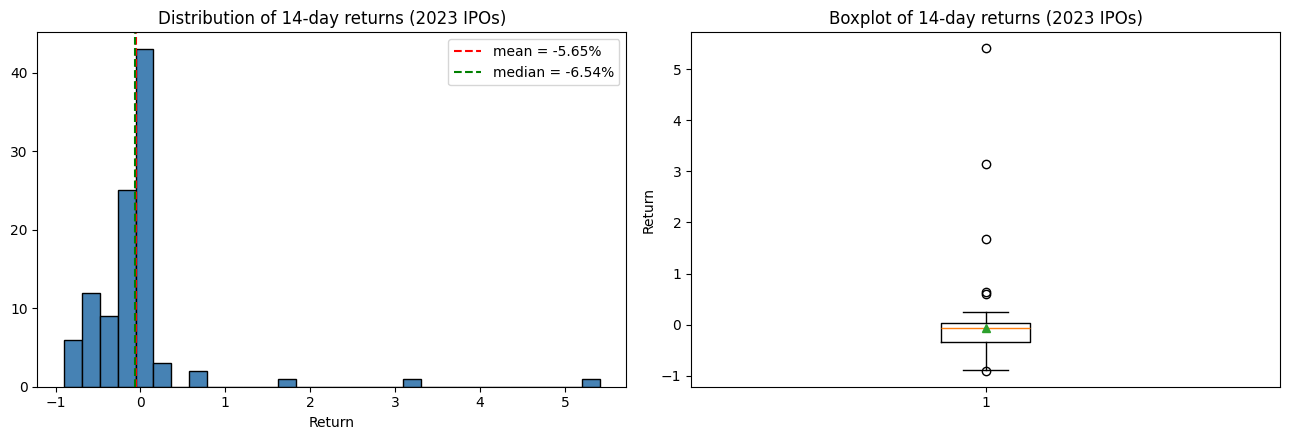

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(returns_at_best_x_2023, bins=30, color='steelblue', edgecolor='black')
axes[0].axvline(summary_2023['mean'], color='red', linestyle='--', label=f"mean = {summary_2023['mean']:.2%}")
axes[0].axvline(summary_2023['median'], color='green', linestyle='--', label=f"median = {summary_2023['median']:.2%}")
axes[0].set_title(f'Distribution of {best_x}-day returns (2023 IPOs)')
axes[0].set_xlabel('Return')
axes[0].legend()

axes[1].boxplot(returns_at_best_x_2023, vert=True, showmeans=True)
axes[1].set_title(f'Boxplot of {best_x}-day returns (2023 IPOs)')
axes[1].set_ylabel('Return')

plt.tight_layout()
plt.show()


**تعليق (تُملأ الأرقام تلقائيًا بعد تشغيل الكود فعليًا، لكن هنا المنطق العام للتفسير):**

- **الفرق بين mean و median:** لو الـ mean أكبر بشكل واضح من الـ median، فده معناه إن فيه عدد قليل من الاكتتابات حققت عوائد ضخمة جدًا (outliers) شدّت المتوسط لفوق، بينما أغلب الاكتتابات عوائدها أقرب للـ median. في الحالة دي الـ **median أكثر موثوقية (robust)** كمقياس للأداء "النموذجي" للاستراتيجية.
- **خسارة في 25% من الحالات:** لو `q25 < 0`، فده معناه إن **ربع الاكتتابات على الأقل** حققت عائد سالب عند الخروج بعد X يوم — يعني الاستراتيجية مش مضمونة، وفيه مخاطرة حقيقية حتى لو الـ mean موجب.

## 6) اختبار نفس X (اللي طلع من 2023) على بيانات 2024 — Out-of-Sample Test

الهدف: نتأكد هل الاستراتيجية اللي "اتحسّنت" على بيانات 2023 (in-sample) لسه شغالة كويس على بيانات جديدة (2024)،
ولا هي **overfit** على خصائص سنة 2023 بالذات.

In [14]:
returns_at_best_x_2024 = returns_2024_df[best_col].dropna()

summary_2024 = {
    'count': returns_at_best_x_2024.count(),
    'mean': returns_at_best_x_2024.mean(),
    'median': returns_at_best_x_2024.median(),
    'std': returns_at_best_x_2024.std(),
    'q25': returns_at_best_x_2024.quantile(0.25),
    'q50': returns_at_best_x_2024.quantile(0.50),
    'q75': returns_at_best_x_2024.quantile(0.75),
    'loss_rate (% < 0)': (returns_at_best_x_2024 < 0).mean(),
}

comparison_df = pd.DataFrame({
    '2023 (in-sample)': summary_2023,
    '2024 (out-of-sample)': summary_2024,
})
display(comparison_df)


,2023 (in-sample),2024 (out-of-sample)
count,103.000000,196.000000
mean,-0.056533,0.006232
median,-0.065385,0.002011
std,0.718398,0.370133
q25,-0.340756,-0.111466
q50,-0.065385,0.002011
q75,0.027137,0.075684
loss_rate (% < 0),0.640777,0.423469


/tmp/ipykernel_1852/65033815.py:2: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



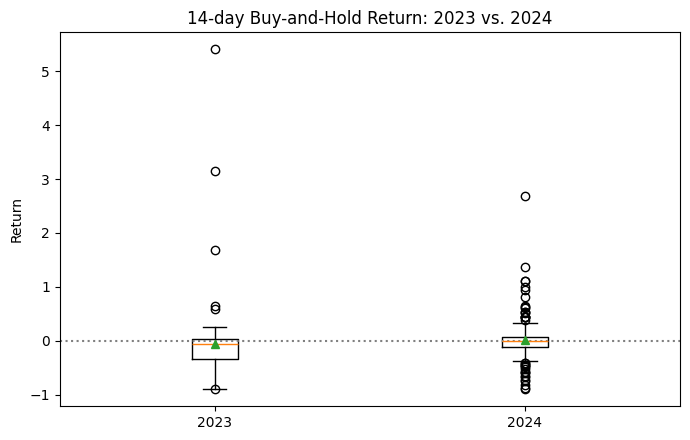

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot([returns_at_best_x_2023, returns_at_best_x_2024], labels=['2023', '2024'], showmeans=True)
ax.axhline(0, color='gray', linestyle=':')
ax.set_title(f'{best_x}-day Buy-and-Hold Return: 2023 vs. 2024')
ax.set_ylabel('Return')
plt.tight_layout()
plt.show()


**تعليق:**

- **الفرق في الأداء بين السنتين:** قارن الـ `mean` والـ `median` بين 2023 و2024 من الجدول فوق. لو العائد في 2024 أقل بشكل واضح (أو حتى سالب)، فده مؤشر إن جزء من الأداء القوي في 2023 كان خاص بظروف تلك السنة (زي شهية المستثمرين للاكتتابات، أو أسماء معينة قفزت بقوة) ومش هيتكرر بالضرورة.
- **Overfitting؟** بما إننا اخترنا X اللي بيعمل *maximum* mean return على 2023 بالذات (30 قيمة اختبرناها)، فده بطبيعته معرّض لـ overfitting — يعني ممكن يكون X ده "لَحَق" ضوضاء (noise) في بيانات 2023 مش نمط حقيقي مستمر. لو الفرق بين أداء 2023 و2024 كبير، ده دليل إضافي على overfitting.
- **توصيات عامة:**
  1. متعتمدش على X واحد "أمثل" بناءً على سنة واحدة فقط — جرّب فترات أطول (عدة سنوات) أو استخدم **cross-validation عبر السنوات**.
  2. اعتمد على الـ **median** بجانب الـ mean، لأنه أقل حساسية للـ outliers (اكتتاب واحد ضخم زي Reddit ممكن يشوّه الصورة).
  3. خد بالك من الـ **loss rate** (نسبة الحالات الخاسرة) مش بس متوسط العائد — استراتيجية عائدها المتوسط موجب لكنها بتخسر في 40% من الحالات مخاطرتها عالية.
  4. جرّب اختبار الاستراتيجية بفلترة إضافية (مثلاً حسب حجم الاكتتاب، أو القطاع) بدل تطبيقها على كل الاكتتابات بنفس الشكل.

## الإجابة النهائية

In [16]:
print(f"أفضل X = {best_x}")
print(f"متوسط العائد في 2023 عند أفضل X = {summary_2023['mean']:.2%}")
print(f"متوسط العائد في 2024 عند نفس X = {summary_2024['mean']:.2%}")
print(f"نسبة الخسارة في 2023 عند 25% quantile (q25) = {summary_2023['q25']:.2%}")


أفضل X = 14
متوسط العائد في 2023 عند أفضل X = -5.65%
متوسط العائد في 2024 عند نفس X = 0.62%
نسبة الخسارة في 2023 عند 25% quantile (q25) = -34.08%


## 7) تحليل إضافي (Bonus)

### 7.1) هل في شهور اكتتاب أفضل من غيرها؟

In [17]:
ipos_2023_with_ret = ipos_2023_clean.merge(
    returns_2023_df[[best_col]], left_on='Symbol', right_index=True, how='left'
)
ipos_2023_with_ret['IPO_Month'] = ipos_2023_with_ret['IPO Date'].dt.month

monthly_perf = ipos_2023_with_ret.groupby('IPO_Month')[best_col].agg(['mean', 'median', 'count'])
display(monthly_perf)

fig = px.bar(monthly_perf.reset_index(), x='IPO_Month', y='mean',
             title=f'2023: Mean {best_x}-day return by IPO month',
             labels={'IPO_Month': 'Month', 'mean': 'Mean return'})
fig.update_layout(title_x=0.5, yaxis_tickformat='.1%')
fig.show()


,mean,median,count
IPO_Month,,,
1,-0.078830,0.042273,5
2,-0.233752,-0.153361,11
3,0.095735,-0.017143,15
4,-0.099805,-0.106329,12
5,-0.197028,-0.057556,4
6,-0.008453,0.048014,9
7,-0.342720,-0.540598,5
8,-0.371261,-0.335536,4
9,-0.271670,-0.260923,13


### 7.2) العلاقة بين حجم IPO Price والعائد

In [18]:
price_vs_return = ipos_2023_with_ret[['IPO Price', best_col]].dropna()
correlation_price_return = price_vs_return['IPO Price'].corr(price_vs_return[best_col])
print(f"Correlation between IPO Price and {best_col}: {correlation_price_return:.3f}")

fig = px.scatter(price_vs_return, x='IPO Price', y=best_col,
                  title=f'IPO Price vs. {best_x}-day Return (2023)',
                  labels={best_col: 'Return'}, trendline='ols')
fig.update_layout(title_x=0.5, yaxis_tickformat='.1%')
fig.show()


Correlation between IPO Price and return_14d: -0.001


### 7.3) Correlation matrix بين العوائد عند X مختلف

In [19]:
sample_x_list = [1, 3, 5, 7, 10, 15, 20, 25, 30]
sample_cols = [f'return_{x}d' for x in sample_x_list]
corr_matrix = returns_2023_df[sample_cols].corr()

fig = px.imshow(corr_matrix, text_auto='.2f', color_continuous_scale='RdBu_r', zmin=-1, zmax=1,
                 title='Correlation matrix between returns at different holding periods (2023)')
fig.update_layout(title_x=0.5)
fig.show()
